$$\text{Today, on the suggestion of my friend, I worked around with Lotka-Volterra Law.}$$
$$\text{It is a beautiful law that integrates two very distinct fields Mathematics and Biology together.}$$
$$\text{It describes the dynamics of interactions between predator and prey populations in ecological systems.}$$
$$\text{By the help of the following two coupled differential Eqautions:}$$
$$\frac{dx}{dt} = \alpha x - \beta xy$$
$$\frac{dy}{dt} = \delta xy - \gamma y$$

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib import animation

In [36]:
def lotka_volterra(t, population, alpha, beta, delta, gamma):
    x, y = population
    dxdt = alpha*x - beta*x*y
    dydt = delta*x*y - gamma*y
    return [dxdt, dydt]

In [37]:
alpha = 0.55    # Fast prey birth rate
beta = 0.02     # Predator hunting efficiency
delta = 0.002   # Small predator conversion rate (takes many prey to make 1 predator)
gamma = 0.30    # Predator natural death rate

In [38]:
initial_population = [100.0, 10.0]
time_span = (0, 60)
time_points = np.linspace(0, 60, 2000)

In [39]:
solution = solve_ivp(
    lotka_volterra, 
    time_span,
    initial_population,
    args=(alpha, beta, delta, gamma),
    t_eval=time_points,
    # I dont know what the below lines means, its just that the 3d plot would not be a perfect cylinder if they aren't used.
    # All i know is that it is to remove the error which python creates while processing.
    rtol = 1e-9, 
    atol = 1e-12
)

In [40]:
time = solution.t
prey_sol = solution.y[0]
pred_sol = solution.y[1]

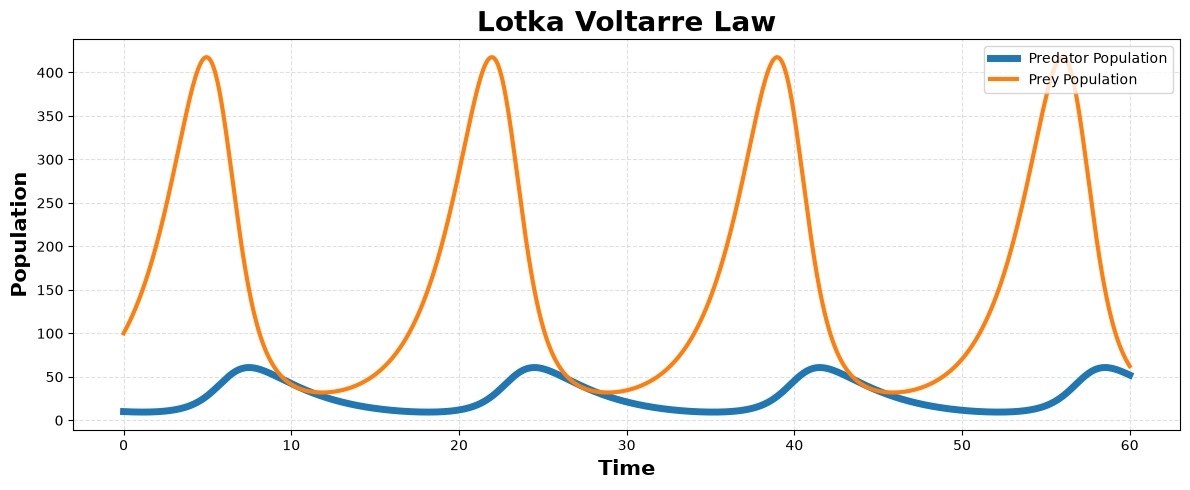

In [41]:
plt.figure(figsize=(12,5))
plt.plot(time, pred_sol, label='Predator Population', linewidth=5)
plt.plot(time, prey_sol, label='Prey Population', linewidth=3)
plt.title('Lotka Volterra Law', fontsize=20, fontweight='bold')
plt.xlabel('Time', fontsize=15, fontweight='bold')
plt.ylabel('Population', fontsize=15, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6, color='#cccccc')
plt.tight_layout()

$$\text{The above plot signifies that, as the population of prey increases, the predator's population increases too.}$$
$$\text{But a point comes when the predators gets to overwhelm the prey population, hence the prey's populations declines.}$$
$$\text{After a little time of predators dominance, it gets to crash too. The predator's crash, gives the prey's population a thrust, and hence rebounces its population.}$$
$$\text{Which in turns, gives another cycle of predator's dominance.}$$
$$\text{Hence, this cycle moves on and on, over eons.}$$

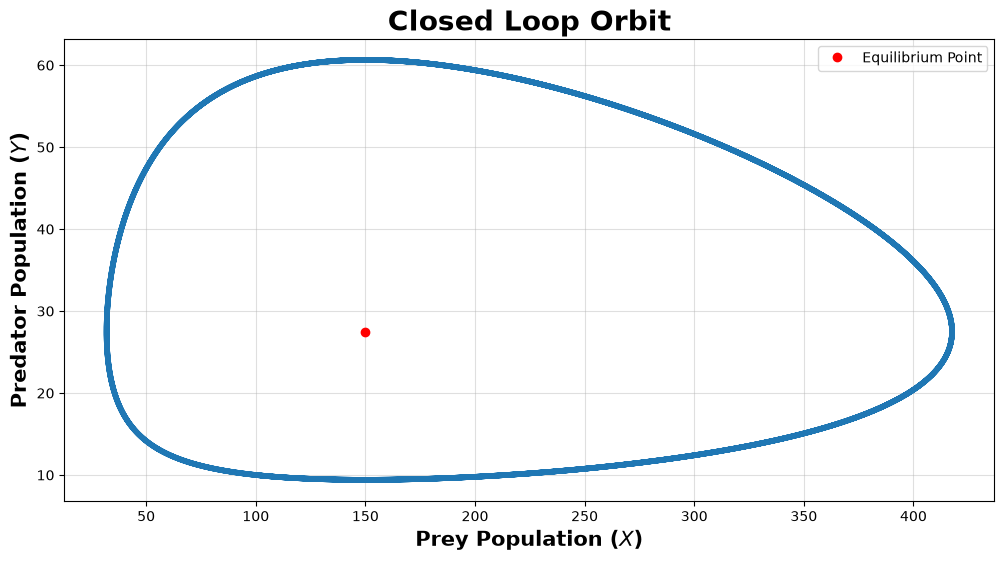

In [53]:
plt.figure(figsize=(12,6))
plt.plot(prey_sol, pred_sol, linewidth=4)
plt.plot(gamma/delta, alpha/beta, 'ro', label='Equilibrium Point')
plt.title('Closed Loop Orbit', fontsize=20, fontweight='bold')
plt.xlabel('Prey Population ($X$)', fontsize=15, fontweight='bold')
plt.ylabel('Predator Population ($Y$)', fontsize=15, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.4)

$$\text{Now let us see the same plot in 3D}$$

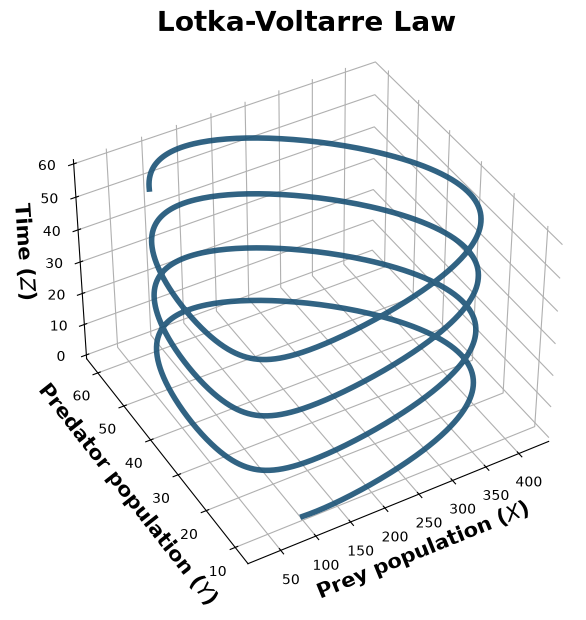

In [43]:
fig, ax =plt.subplots(subplot_kw={'projection':'3d'}, figsize=(6,6))
ax.plot(prey_sol, pred_sol, time, color='#1A5276', linewidth=4, alpha=0.9)

ax.set_title('Lotka-Volterra Law', fontsize=20, fontweight='bold')

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')

ax.set_xlabel('Prey population ($X$)', fontsize=15, fontweight='bold')
ax.set_ylabel('Predator population ($Y$)', fontsize=15, fontweight='bold')
ax.set_zlabel('Time ($Z$)', fontsize=15, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.3, color='gray')

ax.view_init(elev=40, azim=-120)
fig.tight_layout()

$$\text{Please do check out in the media folder under the name LVL.gif, it is a beautiful gif of this 3D plot.}$$

In [44]:
def update(frame):
    if frame <= 360:
        ax.view_init(elev=40, azim=frame)
    else:
        ax.view_init(elev=40 - (frame - 360), azim=0)
    return fig

ani = animation.FuncAnimation(fig, update, frames=np.arange(0, 541, 1), interval=20, blit=False)
ani.save('LVL.gif', writer='pillow', fps=30, dpi=100)

$$\text{Let us do some Calculus}$$

$$\frac{dx}{dt} = \alpha x - \beta xy$$
$$\frac{dy}{dt} = \delta xy - \gamma y$$

$$\text{On dividing Eqation (2) by (1), we gets the following:}$$

$$\frac{dy}{dx} = \frac{\delta xy - \gamma y}{\alpha x - \beta xy}$$
$$\frac{dy}{dx} = \frac{y}{x}(\frac{\delta x - \gamma}{\alpha - \beta y})$$

$$\text{On rearranging, we gets the following:}$$

$$\frac{\alpha - \beta y}{y} dy = \frac{\delta x - \gamma}{x} dx$$
$$(\frac{\alpha}{y} - \beta) dy = (\delta - \frac{\gamma}{x}) dx$$

$$\text{Integrating both sides:}$$

$$\int(\frac{\alpha}{y} - \beta) dy = \int(\delta - \frac{\gamma}{x}) dx$$
$$\alpha \log{y} - \beta y + V = \delta x - \log{x}$$
$$V = \delta x + \beta y - \log{x} - \alpha \log{y} $$

$$\text{For the sake of plotting, we are replacing x to (X-xc) and y to (Y - yc)}$$
$$V = \delta (X - x_c) + \beta (Y - y_c) - \log{\frac{X}{x_c}} - \alpha \log{\frac{Y}{y_C}}  $$

In [45]:
prey_range = np.linspace(5, 450, 40)
pred_range = np.linspace(1, 65, 40)
X, Y = np.meshgrid(prey_range, pred_range)

In [46]:
xc = gamma / delta
yc = alpha / beta
V = delta * (X - xc) + beta * (Y - yc) - gamma * np.log(X/xc) - alpha*np.log(Y/yc)

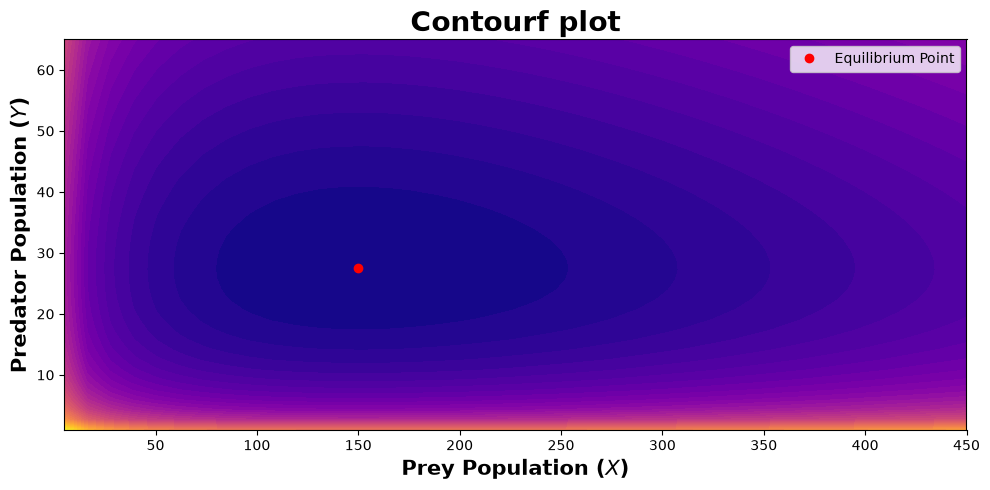

In [47]:
fig, ax= plt.subplots(1, 1, figsize=(10, 5))
ax.contourf(X, Y, V, levels = 40, cmap='plasma')
ax.plot(gamma/delta, alpha/beta, 'ro', label='Equilibrium Point')
ax.set_title('Contourf plot', fontsize=20, fontweight='bold')
ax.set_xlabel('Prey Population ($X$)', fontsize=15, fontweight='bold')
ax.set_ylabel('Predator Population ($Y$)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.legend()

In [48]:
dX = alpha * X - beta * X * Y
dY = delta * X * Y - gamma * Y

arrow_lengths = np.hypot(dX, dY)
dX_normalized = dX / arrow_lengths
dY_normalized = dY / arrow_lengths

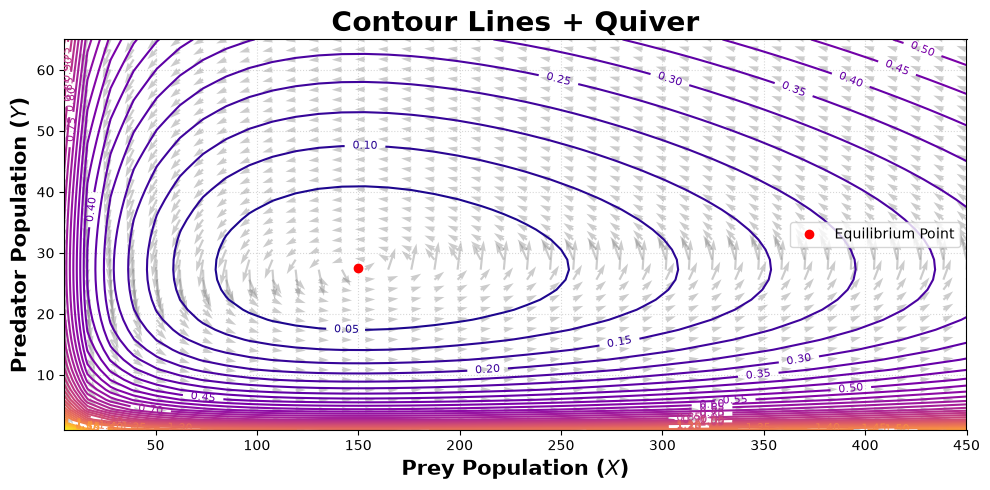

In [49]:
fig, ax= plt.subplots(1, 1, figsize=(10, 5))
contour_lines = ax.contour(X, Y, V, levels = 40, cmap='plasma', linewidth=1.5)

ax.clabel(contour_lines, inline=True, fontsize=8)
plt.quiver(X, Y, dX_normalized, dY_normalized, color='gray',  alpha=0.4, angles='xy', scale_units='xy', scale=0.2)
ax.plot(gamma/delta, alpha/beta, 'ro', label='Equilibrium Point')

ax.set_title('Contour Lines + Quiver', fontsize=20, fontweight='bold')
ax.set_xlabel('Prey Population ($X$)', fontsize=15, fontweight='bold')
ax.set_ylabel('Predator Population ($Y$)', fontsize=15, fontweight='bold')

ax.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()

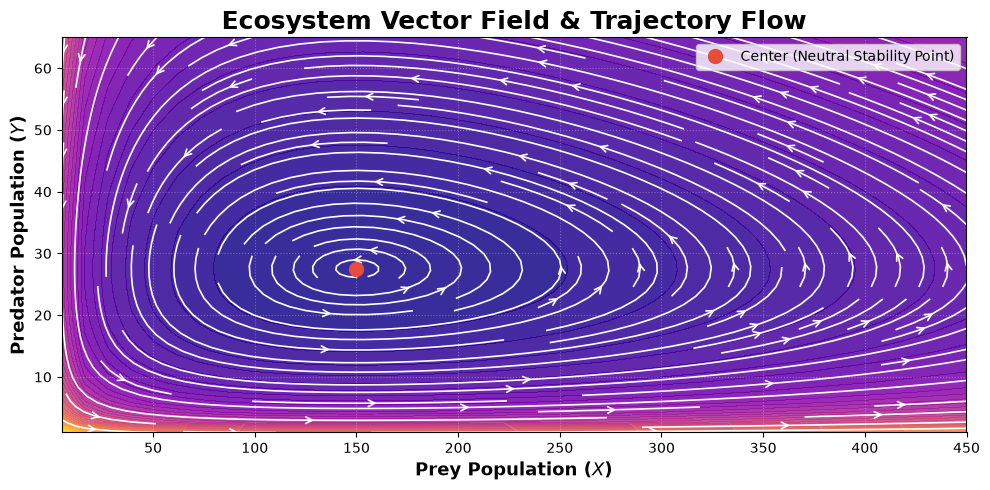

In [50]:
fig, ax= plt.subplots(1, 1, figsize=(10, 5))
contour_fills = ax.contourf(X, Y, V, levels=40, cmap="plasma", alpha=0.85)

flow_field = ax.streamplot(prey_range, pred_range, dX, dY, color="white",linewidth=1.2, density=1.3, arrowstyle="->", arrowsize=1.2,)

ax.plot(gamma / delta, alpha / beta, color="#E74C3C", marker="o", markersize=10, linestyle="None", label="Center (Neutral Stability Point)",)

ax.set_title("Ecosystem Vector Field & Trajectory Flow", fontsize=18, fontweight="bold")
ax.set_xlabel("Prey Population ($X$)", fontsize=13, fontweight="bold")
ax.set_ylabel("Predator Population ($Y$)", fontsize=13, fontweight="bold")

ax.grid(True, linestyle=":", alpha=0.3, color="white")
ax.legend(loc="upper right")

ax.set_xlim(5, 450)
ax.set_ylim(1, 65)

plt.tight_layout()

$$\text{This law is really a great topic.}$$
$$\text{I don't know yet how to make real time simulators, but when i am good at making that, i will pick this law again to make it use on a simulator}$$